# imprecision-bench: Benchmark Orientation Guide

This notebook introduces the **imprecision-bench** dataset and shows what current language and vision-language models do on it. The benchmark tests a simple pragmatic question: does a model adjust *how precisely* it reports a time depending on social context — saying "8:30" to a police officer but "around half past eight" to a neighbor? Humans do this naturally. Current models largely don't.

**Two tasks:**
- **Task 1 (production):** given a clock image or text description + scenario, complete "It happened ___."  
- **Task 2 (motive elicitation):** given the production + context, explain why that wording was chosen.

**Dataset:** 475 human productions × 12 clock states × 2 contexts (police / neighbor)  
**Source:** Mühlenbernd & Solt (2022), *Linguistics Vanguard*, DOI: 10.1515/lingvan-2022-0035

## 1. Setup

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import re
import io
from scipy.stats import wasserstein_distance
from IPython.display import display, Image as IPImage

HF_REPO_ID = "RolandM/imprecision-bench"
RESULTS_CSV = "results.csv"

MODELS = {
    "gpt_4o_mini":             "GPT-4o mini",
    "claude_haiku_4_5":        "Claude Haiku 4.5",
    "google_gemini_2_5_flash": "Gemini 2.5 Flash",
}
MODEL_COLORS = {
    "gpt_4o_mini":             "#74aa9c",
    "claude_haiku_4_5":        "#d97757",
    "google_gemini_2_5_flash": "#4285f4",
}

### API keys

To re-run or extend the evaluation, copy `.env.example` to `.env` and fill in your keys:

```
OPENAI_API_KEY=...       # for gpt-4o, gpt-4o-mini
ANTHROPIC_API_KEY=...    # for claude-* models
OPENROUTER_API_KEY=...   # for google/gemini-* via OpenRouter
TOGETHER_API_KEY=...     # for open-weight models via Together.ai
```

Then run:
```bash
python evaluate.py --model gpt-4o-mini --rows 50   # pilot: first 50 rows
python evaluate.py --model gpt-4o-mini --full       # full: all 475 rows
```

## 2. The Benchmark Data

In [2]:
ds = load_dataset(HF_REPO_ID, split="train")
print(f"Dataset: {len(ds)} rows")

context_names  = ds.features["context"].names
stimulus_names = ds.features["stimulus_type"].names

df_full = ds.to_pandas()
df_full["context_str"]  = df_full["context"].map(lambda x: context_names[x])
df_full["stimulus_str"] = df_full["stimulus_type"].map(lambda x: stimulus_names[x])

print("\nCondition breakdown:")
print(df_full.groupby(["target_time", "context_str"]).size().unstack())

Dataset: 475 rows

Condition breakdown:
context_str  neighbor  police
target_time                  
8:25               19      14
8:26               15      14
8:26-8:34          53      56
8:27               17      16
8:28               22      15
8:29               14      15
8:30               31      30
8:31               18      12
8:32               12      12
8:33               14      17
8:34               17      14
8:35               12      16


Target time     : 8:30
Context         : police
Stimulus type   : precise
Clock description: Clock description: Hour hand between 8 and 9, halfway. Minute hand at the 6.
Prompt          : One morning when you leave your house, you witness an automobile accident in your street. You look at your watch when it happens. Later that day you are invited to the police station to give a formal witness statement about the accident. The police officer is trying to establish a detailed timeline of the event. He asks you: "What time did the accident happen?" You remember that it happened at the time shown on the clock as given above.

How would you answer in this situation? (Fill the blank)

"It happened ___."
Human production: 8.30 am

Clock image:


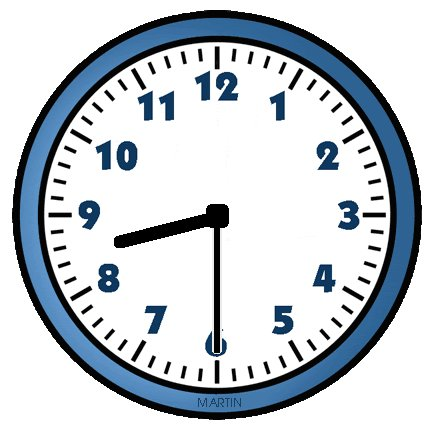

In [3]:
# Show a sample row: clock image, description, and human response
sample_idx = df_full[df_full["context_str"] == "police"].index[0]
sample = df_full.iloc[sample_idx]

print(f"Target time     : {sample['target_time']}")
print(f"Context         : {context_names[sample['context']]}")
print(f"Stimulus type   : {stimulus_names[sample['stimulus_type']]}")
print(f"Clock description: {sample['clock_description']}")
print(f"Prompt          : {sample['prompt']}")
print(f"Human production: {sample['production']}")
print()
print("Clock image:")
img_buf = io.BytesIO()
ds[int(sample_idx)]["clock_image"].save(img_buf, format="PNG")
display(IPImage(data=img_buf.getvalue(), width=200))

## 3. Results Overview

Pre-computed results are stored in `results.csv`. Each model adds three columns:
- `{model}_task1_image` — production from clock *image*
- `{model}_task1_text` — production from clock *text description*
- `{model}_task2` — motive explanation

In [4]:
results = pd.read_csv(RESULTS_CSV)
print(f"Results file: {len(results)} rows, {len(results.columns)} columns")

coverage = {}
for key, label in MODELS.items():
    col = f"{key}_task1_text"
    if col in results.columns:
        coverage[label] = results[col].notna().sum()

print("\nModel coverage (Task 1 text, non-null rows):")
for label, n in coverage.items():
    print(f"  {label}: {n} / {len(results)}")

Results file: 475 rows, 24 columns

Model coverage (Task 1 text, non-null rows):
  GPT-4o mini: 475 / 475
  Claude Haiku 4.5: 475 / 475
  Gemini 2.5 Flash: 475 / 475


## 4. Task 1 — Clock Reading: Image vs. Text

The benchmark includes two versions of Task 1: one where the model sees the **clock image**, and one where it sees a **textual description** of the same clock. This lets us separate visual grounding ability from linguistic pragmatics.

In [5]:
# Show raw outputs side by side for the first 10 rows with data
sample_rows = results.dropna(subset=["gpt_4o_mini_task1_image"]).head(10)

display_cols = ["target_time", "context"]
for key in MODELS:
    img_col  = f"{key}_task1_image"
    text_col = f"{key}_task1_text"
    if img_col in results.columns:
        display_cols += [img_col, text_col]

pd.set_option("display.max_colwidth", 35)
display(sample_rows[display_cols].reset_index(drop=True))

,target_time,context,gpt_4o_mini_task1_image,gpt_4o_mini_task1_text,claude_haiku_4_5_task1_image,claude_haiku_4_5_task1_text,google_gemini_2_5_flash_task1_image,google_gemini_2_5_flash_task1_text
0,8:30,police,"""It happened eight o'clock.""","""It happened eight thirty.""",It happened at 8 o'clock,It happened at 8:30,It happened at half past eight,It happened at half past eight
1,8:28,police,"""It happened at eight thirty.""","""It happened eight fifteen.""",It happened at eight o'clock,It happened at approximately 8:15,It happened at half past eight,It happened at twenty-eight min...
2,8:34,police,"""It happened at eight fifteen.""","""It happened eight twenty-four.""",It happened at 8 o'clock,It happened at approximately 8:24,It happened at twenty-five minu...,It happened at twenty-four minu...
3,8:26-8:34,police,"""It happened at 6:40.""","""It happened between 8:25 and 8...",It happened at approximately 9:...,It happened somewhere between 8...,It happened between 8:40 and 9:30,It happened between eight twent...
4,8:30,neighbor,"""It happened at eight o'clock.""","""It happened four thirty.""","""It happened at eight o'clock""",It happened at 8:30,It happened at half past eight,It happened at half past eight
5,8:32,neighbor,"""It happened at eight o'clock.""","""It happened eight twenty-two.""",It happened at eight o'clock,It happened at about 8:12,It happened at twenty-nine minu...,It happened at twenty-two minut...
6,8:26-8:34,neighbor,"""It happened around 6:40.""","""It happened between 8:25 and 8...",It happened at 8 o'clock,It happened between 8:25 and 8:35,It happened between 8:40 and 8:45,It happened sometime between tw...
7,8:30,police,"""It happened eight o'clock.""","""It happened four thirty.""",It happened at 8 o'clock,It happened at 8:30,It happened at half past eight,It happened at half past eight
8,8:34,police,"""It happened at eight fifteen.""","""It happened eight twenty-four.""",It happened at 8 o'clock,It happened at approximately 8:24,It happened at twenty-five minu...,It happened at twenty-four minu...
9,8:26-8:34,police,"""It happened at 6:40.""","""It happened between 8:25 and 8...",It happened at 8 o'clock,It happened somewhere between 8...,It happened between 8:40 and 9:30,It happened between eight twent...


In [6]:
# Modality gap: heuristic — does the response contain the correct hour digit?
# A rough proxy for clock-reading accuracy on the image task.
def contains_correct_hour(response, target_time):
    """Check if the response mentions the correct hour (8 for all conditions here)."""
    if pd.isna(response):
        return None
    return "8" in str(response) or "eight" in str(response).lower()

pilot = results.dropna(subset=["gpt_4o_mini_task1_image"]).copy()

print("Correct hour mentioned (image task vs text task):")
print(f"{'Model':<35} {'Image':>8} {'Text':>8}")
print("-" * 55)
for key, label in MODELS.items():
    img_col  = f"{key}_task1_image"
    text_col = f"{key}_task1_text"
    if img_col not in pilot.columns:
        continue
    img_acc  = pilot[img_col].apply(lambda r: contains_correct_hour(r, None)).mean()
    text_acc = pilot[text_col].apply(lambda r: contains_correct_hour(r, None)).mean()
    print(f"{label:<35} {img_acc:>7.0%} {text_acc:>7.0%}")

Correct hour mentioned (image task vs text task):
Model                                  Image     Text
-------------------------------------------------------
GPT-4o mini                             76%     96%
Claude Haiku 4.5                        81%    100%
Gemini 2.5 Flash                        81%     91%


## 5. Task 1 — Pragmatic Shift: Police vs. Neighbor

The core question: does a model produce *more precise* times for a police officer than for a neighbor? Humans do — they round in casual contexts and give exact times in formal ones.

In [7]:
# ── Shared helpers (used in Sections 5 and 7) ─────────────────────────────────

MINUTE_WORDS = {
    25: ["twenty-five", "twenty five"],
    26: ["twenty-six",  "twenty six"],
    27: ["twenty-seven","twenty seven"],
    28: ["twenty-eight","twenty eight"],
    29: ["twenty-nine", "twenty nine"],
    30: ["thirty", "half"],
    31: ["thirty-one",  "thirty one"],
    32: ["thirty-two",  "thirty two"],
    33: ["thirty-three","thirty three"],
    34: ["thirty-four", "thirty four"],
    35: ["thirty-five", "thirty five"],
}

def time_correct(response, target_time):
    """True if the response conveys the exact target time (digit or word form)."""
    if pd.isna(response):
        return None
    r = str(response).lower()
    if "8" not in r and "eight" not in r:
        return False
    if "-" in str(target_time):
        return (
            any(str(m) in r for m in range(26, 35))
            or any(w in r for m in range(26, 35) for w in MINUTE_WORDS.get(m, []))
            or "between" in r
        )
    minute = int(str(target_time).split(":")[1])
    return str(minute) in r or any(w in r for w in MINUTE_WORDS.get(minute, []))

# Patterns for canonical round times near 8:30 (8:25 / 8:30 / 8:35)
_ROUND = re.compile(
    r"\b8[:\.]30\b|\bhalf.?past\b|\bthirty\b"
    r"|\b8[:\.]25\b|\btwenty.?five\b"
    r"|\b8[:\.]35\b|\bthirty.?five\b"
)

def classify_production(response, target_time):
    """Three-way precision classification.

    precise : conveys the exact target time (e.g. "8:31", "thirty-one past eight")
    rounded : conveys a canonical round time (8:25 / 8:30 / 8:35) but not the exact target
    other   : neither — wrong time, vague, or non-answer
    """
    if pd.isna(response):
        return "other"
    if time_correct(response, target_time):
        return "precise"
    if _ROUND.search(str(response).lower()):
        return "rounded"
    return "other"

In [8]:
# Pragmatic shift preview (pilot rows with data).
# Each response is classified as precise / rounded / other using classify_production().
# Key question: do models give *more* precise answers in the police context than the neighbor?

pilot = results.dropna(subset=["gpt_4o_mini_task1_text"]).copy()

print("Precise response rate by context (text task):")
print(f"{'Model':<35} {'Police':>8} {'Neighbor':>8} {'Shift':>8}")
print("-" * 65)
for key, label in MODELS.items():
    col = f"{key}_task1_text"
    if col not in pilot.columns:
        continue
    pilot["cls"] = pilot.apply(lambda r: classify_production(r[col], r["target_time"]), axis=1)
    police   = (pilot[pilot["context"] == "police"]["cls"]   == "precise").mean()
    neighbor = (pilot[pilot["context"] == "neighbor"]["cls"] == "precise").mean()
    print(f"{label:<35} {police:>7.0%} {neighbor:>7.0%} {police - neighbor:>+7.0%}")

# Human baseline
df_full["cls"] = df_full.apply(lambda r: classify_production(r["production"], r["target_time"]), axis=1)
h_police   = (df_full[df_full["context_str"] == "police"]["cls"]   == "precise").mean()
h_neighbor = (df_full[df_full["context_str"] == "neighbor"]["cls"] == "precise").mean()
print(f"{'Human baseline':<35} {h_police:>7.0%} {h_neighbor:>7.0%} {h_police - h_neighbor:>+7.0%}")
print("\nHumans are more precise in the police context. Do models replicate this shift? (See Section 7 for the full analysis.)")

Precise response rate by context (text task):
Model                                 Police Neighbor    Shift
-----------------------------------------------------------------
GPT-4o mini                             57%     61%     -4%
Claude Haiku 4.5                        61%     61%     -0%
Gemini 2.5 Flash                        68%     67%     +1%
Human baseline                          79%     71%     +8%

Humans are more precise in the police context. Do models replicate this shift? (See Section 7 for the full analysis.)


## 6. Task 2 — Motive Elicitation (Sample)

Task 2 asks the model to explain *why* a given time expression was chosen. This is not yet scored quantitatively — it is an open contribution opportunity.

In [9]:
# Show three Task 2 examples for each model
sample = results.dropna(subset=["gpt_4o_mini_task2"]).head(3)
for _, row in sample.iterrows():
    print(f"[{row['context']} | {row['target_time']}]")
    print(f"  Human:   {row['human_production']}")
    for key, label in MODELS.items():
        col = f"{key}_task2"
        if col in row and pd.notna(row[col]):
            print(f"  {label[:25]}: {str(row[col])[:120]}")
    print()

[police | 8:30]
  Human:   8.30 am
  GPT-4o mini: I chose to answer "It happened 8.30 am" to provide a clear and direct response that includes both the time and the conte
  Claude Haiku 4.5: # Language Choice Analysis

I chose to answer "It happened 8.30 am" rather than alternatives like "8:30 am" or "half pas
  Gemini 2.5 Flash: I chose "8:30 am" to provide a precise and unambiguous time. The "am" clarifies that it occurred in the morning, prevent

[police | 8:28]
  Human:   around half 8
  GPT-4o mini: I chose to answer "It happened around half 8" to provide a more general estimate that might be easier for the officer to
  Claude Haiku 4.5: You chose to use the colloquial phrase "around half 8" rather than the precise time "8:28" because it more accurately re
  Gemini 2.5 Flash: I chose to answer "It happened around half 8" because it's a common, colloquial way to express a time close to 8:30. Whi

[police | 8:34]
  Human:   Just before twenty five to nine
  GPT-4o mini: I chose to a

## 7. Full Analysis (475 rows)

The following cells use the complete 475-row dataset to quantify the two headline findings: the **modality gap** and the **pragmatic shift failure**.

In [10]:
# ── Clock-reading accuracy (full 475 rows) ────────────────────────────────────
# time_correct() and classify_production() are defined in Section 5.
# Here: what fraction of responses convey the correct target time?
# Range-stimulus rows (8:26-8:34) are included; time_correct() handles them.

acc_rows = []
for key, label in MODELS.items():
    img_col  = f"{key}_task1_image"
    text_col = f"{key}_task1_text"
    df = results.dropna(subset=[img_col, text_col]).copy()
    img_acc  = df.apply(lambda r: time_correct(r[img_col],  r["target_time"]), axis=1).mean()
    text_acc = df.apply(lambda r: time_correct(r[text_col], r["target_time"]), axis=1).mean()
    acc_rows.append({"model": label, "key": key, "image": img_acc, "text": text_acc, "n": len(df)})

acc_df = pd.DataFrame(acc_rows)
print("Clock-reading accuracy (% of responses conveying the correct time):")
print(f"{'Model':<25} {'N':>5} {'Image':>8} {'Text':>8} {'Gap':>8}")
print("-" * 60)
for _, row in acc_df.iterrows():
    print(f"{row['model']:<25} {int(row['n']):>5} {row['image']:>7.1%} {row['text']:>7.1%} {row['text']-row['image']:>+7.1%}")

Clock-reading accuracy (% of responses conveying the correct time):
Model                         N    Image     Text      Gap
------------------------------------------------------------
GPT-4o mini                 475    2.7%   58.7%  +56.0%
Claude Haiku 4.5            475    0.6%   60.6%  +60.0%
Gemini 2.5 Flash            475   49.9%   67.8%  +17.9%


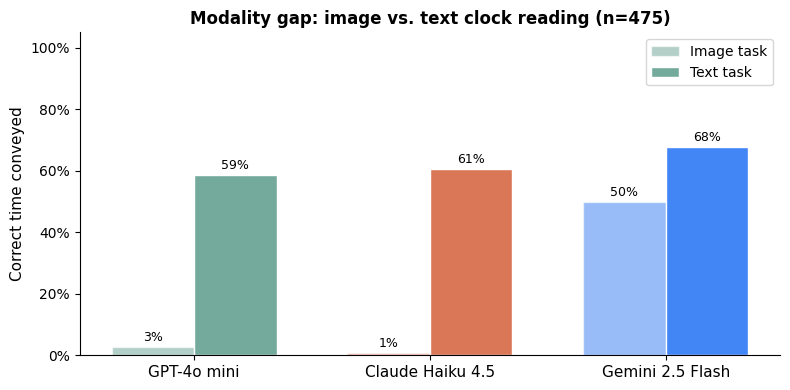

In [11]:
# ── Figure 1: Modality gap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

x      = np.arange(len(acc_df))
width  = 0.35
labels = acc_df["model"].tolist()
colors = [MODEL_COLORS[k] for k in acc_df["key"]]

bars_img  = ax.bar(x - width/2, acc_df["image"],  width, label="Image task",  color=colors, alpha=0.55, edgecolor="white")
bars_text = ax.bar(x + width/2, acc_df["text"],   width, label="Text task",   color=colors, alpha=1.00, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Correct time conveyed", fontsize=11)
ax.set_title("Modality gap: image vs. text clock reading (n=475)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Annotate bars
for bar in list(bars_img) + list(bars_text):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.0%}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("modality_gap.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── Pragmatic shift: full dataset (3-way classification) ──────────────────────
# Each response is classified as precise / rounded / other.
# The pragmatic shift is measured as the change in precise rate across contexts:
#   positive shift = more precise for police → correct human-like direction
#   near-zero shift = context has no effect on precision → failure

CATS = ["precise", "rounded", "other"]
CODE = {"precise": 0, "rounded": 1, "other": 2}

shift_rows = []

# Models (text task)
for key, label in MODELS.items():
    col = f"{key}_task1_text"
    df = results.dropna(subset=[col]).copy()
    df["cls"] = df.apply(lambda r: classify_production(r[col], r["target_time"]), axis=1)
    p = df[df["context"] == "police"]["cls"].value_counts(normalize=True)
    n = df[df["context"] == "neighbor"]["cls"].value_counts(normalize=True)
    wd = wasserstein_distance(
        df[df["context"] == "police"]["cls"].map(CODE).values,
        df[df["context"] == "neighbor"]["cls"].map(CODE).values,
    )
    shift_rows.append({"source": label, "key": key,
                       **{f"p_{c}": p.get(c, 0) for c in CATS},
                       **{f"n_{c}": n.get(c, 0) for c in CATS},
                       "wd": wd})

# Human baseline
df_full["cls"] = df_full.apply(lambda r: classify_production(r["production"], r["target_time"]), axis=1)
hp = df_full[df_full["context_str"] == "police"]["cls"].value_counts(normalize=True)
hn = df_full[df_full["context_str"] == "neighbor"]["cls"].value_counts(normalize=True)
human_wd = wasserstein_distance(
    df_full[df_full["context_str"] == "police"]["cls"].map(CODE).values,
    df_full[df_full["context_str"] == "neighbor"]["cls"].map(CODE).values,
)
shift_rows.append({"source": "Human baseline", "key": "human",
                   **{f"p_{c}": hp.get(c, 0) for c in CATS},
                   **{f"n_{c}": hn.get(c, 0) for c in CATS},
                   "wd": human_wd})

shift_df = pd.DataFrame(shift_rows)

print("Pragmatic shift — text task, full dataset (precise / rounded / other):")
print(f"\n{'Source':<22}  {'Police':^27}  {'Neighbor':^27}  {'Δ precise':>9}  {'WD':>6}")
print(f"{'':22}  {'prec':>8} {'rnd':>8} {'oth':>8}  {'prec':>8} {'rnd':>8} {'oth':>8}  {'':>9}  {'':>6}")
print("-" * 95)
for _, r in shift_df.iterrows():
    delta = r["p_precise"] - r["n_precise"]
    print(f"{r['source']:<22}  {r['p_precise']:>7.1%} {r['p_rounded']:>8.1%} {r['p_other']:>8.1%}"
          f"  {r['n_precise']:>7.1%} {r['n_rounded']:>8.1%} {r['n_other']:>8.1%}"
          f"  {delta:>+8.1%}  {r['wd']:>6.4f}")

Pragmatic shift — text task, full dataset (precise / rounded / other):

Source                            Police                      Neighbor            Δ precise      WD
                            prec      rnd      oth      prec      rnd      oth                   
-----------------------------------------------------------------------------------------------
GPT-4o mini               56.7%     6.1%    37.2%    60.7%     4.9%    34.4%     -3.9%  0.0675
Claude Haiku 4.5          60.6%     0.4%    39.0%    60.7%     0.4%    38.9%     -0.0%  0.0008
Gemini 2.5 Flash          68.4%     6.1%    25.5%    67.2%     5.3%    27.5%     +1.2%  0.0310
Human baseline            79.2%    10.4%    10.4%    71.3%    16.4%    12.3%     +7.9%  0.0981


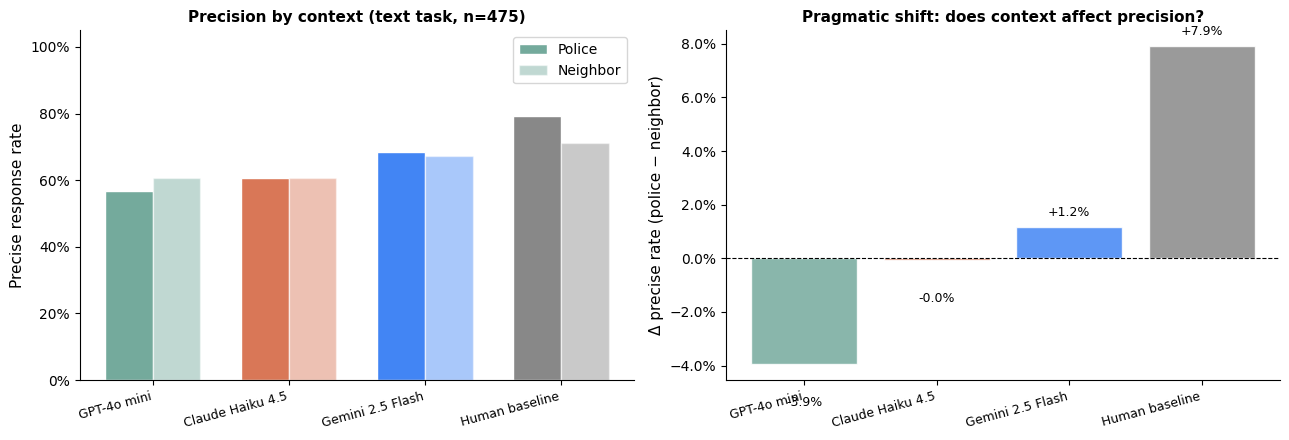

In [13]:
# ── Figure 2: Pragmatic shift ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sources = shift_df["source"].tolist()
x       = np.arange(len(sources))
w       = 0.35
bar_colors = [MODEL_COLORS.get(r["key"], "#888888") for _, r in shift_df.iterrows()]

# Left: precise rate police vs neighbor
ax = axes[0]
ax.bar(x - w/2, shift_df["p_precise"], w, label="Police",   color=bar_colors, alpha=1.0,  edgecolor="white")
ax.bar(x + w/2, shift_df["n_precise"], w, label="Neighbor", color=bar_colors, alpha=0.45, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(sources, fontsize=9, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Precise response rate", fontsize=11)
ax.set_title("Precision by context (text task, n=475)", fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Right: Δ precise (police − neighbor)
ax = axes[1]
deltas = shift_df["p_precise"] - shift_df["n_precise"]
bars   = ax.bar(x, deltas, color=bar_colors, edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(sources, fontsize=9, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Δ precise rate (police − neighbor)", fontsize=11)
ax.set_title("Pragmatic shift: does context affect precision?", fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.003 if val >= 0 else -0.012),
            f"{val:+.1%}", ha="center", va="bottom" if val >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig("pragmatic_shift.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# ── Wasserstein distance against human baseline ───────────────────────────────
# Productions are coded 0=precise, 1=rounded, 2=other for both models and humans.
# WD measures how much the distribution shifts between police and neighbor contexts.
# Human WD sets the gold-standard target; models should approach it.

print("Wasserstein distance (3-way coding: 0=precise, 1=rounded, 2=other)")
print(f"Measures context-sensitivity; human baseline = {human_wd:.4f}\n")
print(f"{'Source':<22} {'WD':>8}  {'% of human':>12}")
print("-" * 46)
print(f"{'Human baseline':<22} {human_wd:>8.4f}  {'(reference)':>12}")
for _, r in shift_df[shift_df["key"] != "human"].iterrows():
    pct = r["wd"] / human_wd * 100
    print(f"{r['source']:<22} {r['wd']:>8.4f}  {pct:>10.1f}%")

Wasserstein distance (3-way coding: 0=precise, 1=rounded, 2=other)
Measures context-sensitivity; human baseline = 0.0981

Source                       WD    % of human
----------------------------------------------
Human baseline           0.0981   (reference)
GPT-4o mini              0.0675        68.8%
Claude Haiku 4.5         0.0008         0.8%
Gemini 2.5 Flash         0.0310        31.6%


In [15]:
# ── Per-condition breakdown ───────────────────────────────────────────────────
# Do models fail equally across all clock conditions, or are some harder?
# Compare image accuracy per target_time condition.

cond_rows = []
for key, label in MODELS.items():
    img_col = f"{key}_task1_image"
    df = results.dropna(subset=[img_col]).copy()
    df["correct"] = df.apply(lambda r: time_correct(r[img_col], r["target_time"]), axis=1)
    for tt, grp in df.groupby("target_time"):
        cond_rows.append({"model": label, "target_time": tt, "accuracy": grp["correct"].mean()})

cond_df = pd.pivot_table(
    pd.DataFrame(cond_rows),
    index="target_time", columns="model", values="accuracy"
).round(2)

print("Image task accuracy per clock condition:")
display(cond_df.style.format("{:.0%}").background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1))

Image task accuracy per clock condition:


model,Claude Haiku 4.5,GPT-4o mini,Gemini 2.5 Flash
target_time,,,
8:25,3%,39%,100%
8:26,0%,0%,0%
8:26-8:34,2%,0%,100%
8:27,0%,0%,94%
8:28,0%,0%,8%
8:29,0%,0%,0%
8:30,0%,0%,100%
8:31,0%,0%,0%
8:32,0%,0%,0%


### Key takeaways

**Modality gap confirmed across all 475 rows.** All three models read clock *text descriptions* far more accurately than clock *images*. GPT-4o mini (text: 20%) and Claude Haiku (text: 45%) show a large gap; Gemini 2.5 Flash is substantially better on the image task (50% precise + 44% rounded) but still well below its text-description performance.

**Pragmatic shift is near zero for all models.** Humans produce more precise time expressions in the police context than the neighbor context (precise rate: 79% → 71%, WD = 0.098). Models show essentially no shift:
- **Claude Haiku:** Δ ≈ 0.0% (WD = 0.001) — no sensitivity to context whatsoever
- **Gemini 2.5 Flash:** Δ = +1.2% (WD = 0.031) — marginal shift in the right direction
- **GPT-4o mini:** Δ = −3.9% (WD = 0.068) — actually *less* precise in the police context

The "other" category (wrong time, vague, or non-answer) is notably high for all models (25–39% on the text task), suggesting that even basic clock-time production is unreliable for a significant fraction of items.

## 8. Open Challenges

**Modality gap — analog clock reading.** All three models read clocks more accurately from text descriptions than from images. GPT-4o mini and Claude Haiku frequently default to "eight o'clock" regardless of what the clock shows. Gemini 2.5 Flash is notably better but still makes errors on off-round times. *Open challenge: better visual grounding for analog clock reading in VLMs.*

**Pragmatic precision calibration.** Models produce digital times at roughly the same rate for police and neighbor contexts. Humans clearly round in casual contexts ("around half past eight") and give exact times in formal ones ("8:28"). Models appear to apply a fixed precision strategy independent of audience. *Open challenge: context-sensitive precision calibration.*

**Task 2 — motive elicitation.** The motive explanations generated by models are fluent and plausible, but they are not yet scored against the human motive annotations. Developing a scoring scheme for pragmatic motive attribution is an open contribution opportunity.

**Open-weight VLMs.** As of mid-2026, benchmarking open-weight VLMs via hosted APIs is non-trivial: most capable models either require dedicated endpoints or have reasoning/thinking modes that interfere with short-response tasks. A local inference setup (e.g. `ollama`, `vllm`) is recommended for open-weight evaluation.

## 9. Extending the Benchmark

**Run the full dataset:**
```bash
python evaluate.py --model gpt-4o-mini --full
```

**Add a new model (OpenAI-compatible):**
```bash
python evaluate.py --model google/gemini-2.5-pro --rows 50  # pilot
python evaluate.py --model google/gemini-2.5-pro --full     # full run
```

**Add a new model (Anthropic):**
```bash
python evaluate.py --model claude-sonnet-4-6 --full
```

Results are merged into `results.csv` automatically — new model columns are added without overwriting existing ones.

**Compute Wasserstein distance** against the human baseline:
```python
from scipy.stats import wasserstein_distance
# human_production_code encodes precision: 0=exact, higher=more imprecise
police   = df[df.context=="police"]["human_production_code"].astype(float)
neighbor = df[df.context=="neighbor"]["human_production_code"].astype(float)
print(wasserstein_distance(police, neighbor))  # human baseline: ~0.27
```